In [15]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import timeit

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

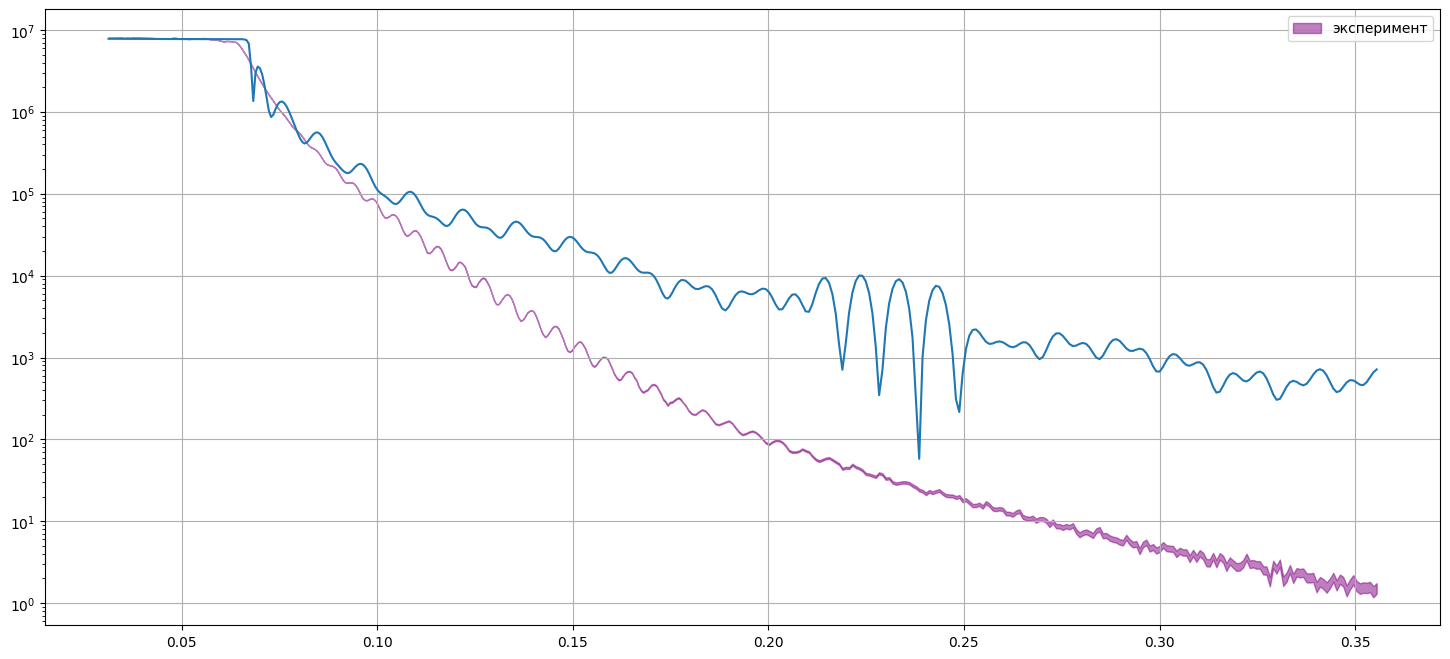

In [16]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.5406
r_mod, r_mod_conv= reflectometry(q, matr, initial_sigma1, initial_sigma2, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r-delta_r, r+delta_r, color='purple', alpha=0.5, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist())
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

r = torch.tensor(r/I0.cpu().detach().numpy())

In [17]:
from objective_function import *

loss_function = Comparator(q, r, delta_r, I0)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)
objective_function_pearson = varbounds(all_bounds, loss_function.pearson)

In [18]:
objective_function_weightless.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), initial_delta_q, initial_sigma1, initial_sigma2, I0, Ibkg)

tensor(7213140.9665, dtype=torch.float64, grad_fn=<SumBackward0>)

In [19]:
objective_function.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), initial_delta_q, initial_sigma1, initial_sigma2, I0, Ibkg)

tensor(0.6042, dtype=torch.float64, grad_fn=<SumBackward0>)

In [20]:
objective_function_pearson.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), initial_delta_q, initial_sigma1, initial_sigma2, I0, Ibkg)

tensor(309.8689, dtype=torch.float64, grad_fn=<SumBackward0>)

In [21]:
N = q.shape[0]
n_split = N // 3  

q1 = q[:n_split]             
q2 = q[:2*n_split]
q3 = q[:3*n_split:]

r1 = r[:n_split]             
r2 = r[:2*n_split]
r3 = r[:3*n_split]

relative_loss:   1.0 
 structure: 
 tensor([[819.8800+0.0000j,  88.5150-7.6428j, 350.0000+0.0000j],
        [ 20.1200+0.0000j,   7.4400-0.0000j,   5.1200+0.0000j],
        [100.0000+0.0000j,   8.5150-0.2109j,  70.1200+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[  0.8232+0.0000j,  12.7465+9.5177j,  -0.0656+0.0000j],
        [ -1.4727+0.0000j,   3.4020+18.7236j, -17.1447+0.0000j],
        [  0.0000+0.0000j,   3.7393+5.8940j,  -1.4786+0.0000j]]) 
 delta_q:   tensor(47638.1914, requires_grad=True) 
 grad_delta_q:   tensor(-1.0294e-06) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.12 
 iteration:   1 



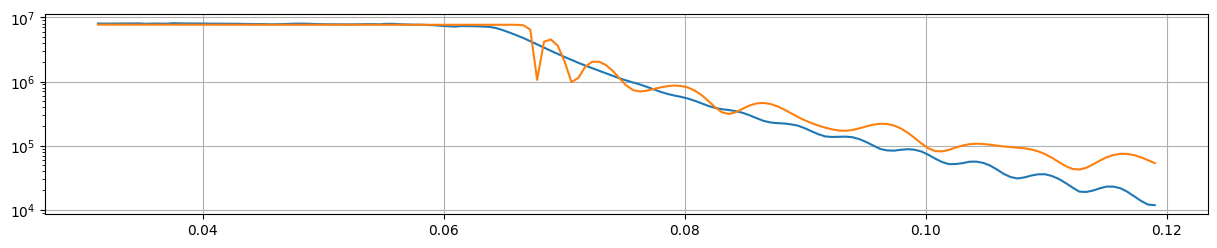

relative_loss:   0.24342852516043714 
 structure: 
 tensor([[812.6394+0.0000j,  80.0000-6.9076j, 345.0019+0.0000j],
        [ 28.0622+0.0000j,   7.0000-0.0000j,  19.3025+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  78.1379+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 0.0739+0.0000j,  2.6567+2.2329j, -0.1153+0.0000j],
        [ 0.0796+0.0000j,  1.5700+5.6276j, -4.8975+0.0000j],
        [ 0.0000+0.0000j,  0.9381+0.6685j,  0.0775+0.0000j]]) 
 delta_q:   tensor(4919052., requires_grad=True) 
 grad_delta_q:   tensor(-3.1503e-08) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.10630108570367998 
 iteration:   134 



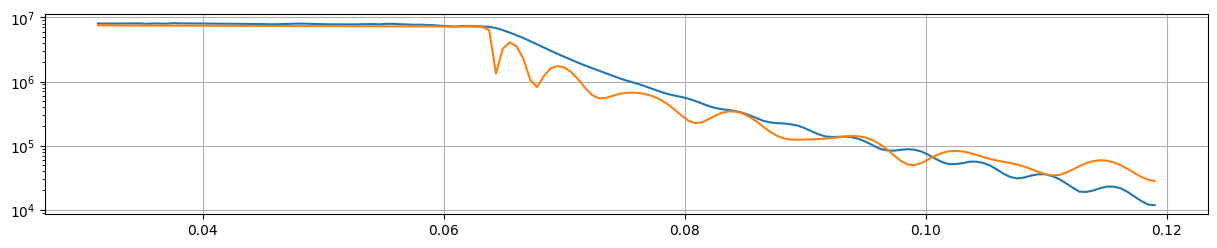

relative_loss:   0.23194512792974273 
 structure: 
 tensor([[808.6723+0.0000j,  80.0000-6.9076j, 347.1455+0.0000j],
        [ 28.5631+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  78.6986+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.3470e-01+0.0000j,  2.5562e+00+1.8849j,  1.9729e-03+0.0000j],
        [ 1.5048e-01+0.0000j,  1.3810e+00+5.0520j, -4.6964e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  9.2213e-01+0.5677j,  1.4860e-01+0.0000j]]) 
 delta_q:   tensor(6395888.5000, requires_grad=True) 
 grad_delta_q:   tensor(-1.5471e-07) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.09228268671121245 
 iteration:   267 



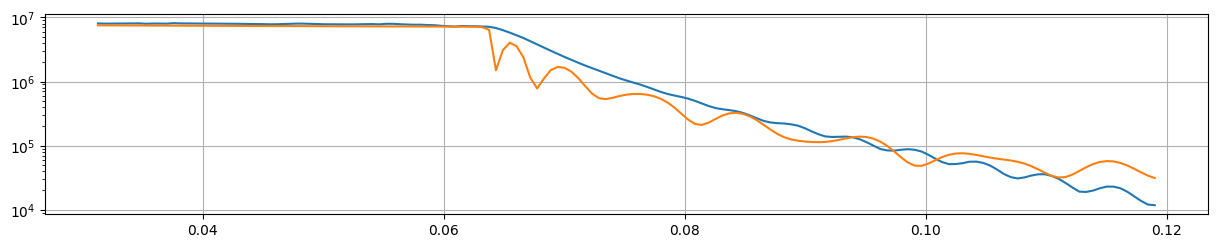

relative_loss:   0.2291397769314054 
 structure: 
 tensor([[812.8881+0.0000j,  80.0000-6.9076j, 347.1086+0.0000j],
        [ 28.2990+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  78.4809+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 0.0892+0.0000j,  2.6932+1.8170j, -0.0598+0.0000j],
        [-0.0714+0.0000j,  1.4069+5.0577j, -4.4105+0.0000j],
        [ 0.0000+0.0000j,  0.8085+0.6476j, -0.0732+0.0000j]]) 
 delta_q:   tensor(8737709., requires_grad=True) 
 grad_delta_q:   tensor(-2.0850e-07) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.08011295661061131 
 iteration:   400 



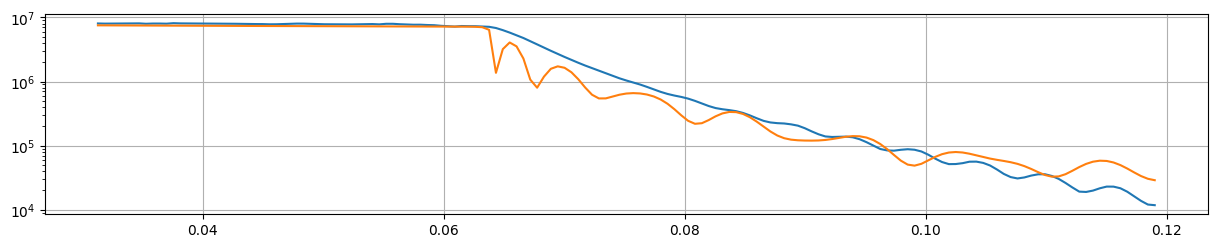

In [22]:
from optimizer import *
ans_d, ans_r_rho, ans_i_rho, ans_delta_q, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q1, initial_delta_q, r1, objective_function_pearson.objective_function, initial_sigma1, initial_sigma2,
                                                                      initial_d, initial_r_rho, initial_i_rho, I0, Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.006, max_iter = 400, k=4)


relative_loss:   1.0 
 structure: 
 tensor([[812.8481+0.0000j,  80.0000-6.9076j, 347.1486+0.0000j],
        [ 28.3390+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  78.5209+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 0.0906+0.0000j,  2.6891+1.8173j, -0.0611+0.0000j],
        [-0.0694+0.0000j,  1.4066+5.0570j, -4.4104+0.0000j],
        [ 0.0000+0.0000j,  0.8076+0.6465j, -0.0712+0.0000j]]) 
 delta_q:   tensor(8752968., requires_grad=True) 
 grad_delta_q:   tensor(-2.0606e-07) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.04 
 iteration:   1 



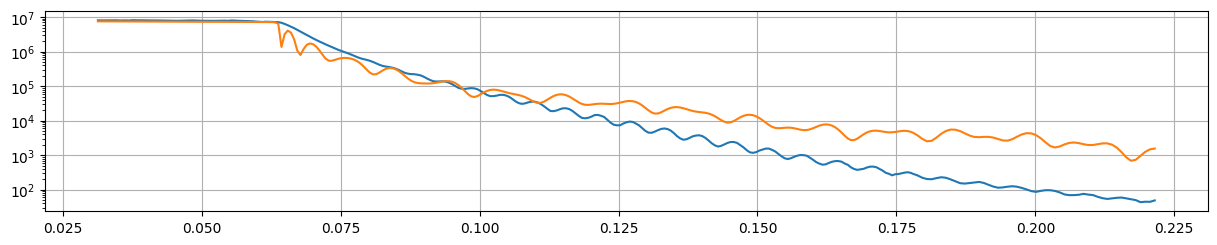

relative_loss:   0.9943109349172634 
 structure: 
 tensor([[812.5497+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 28.4863+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  79.2745+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 1.2770e-02+0.0000j,  2.3041e+00+1.8730j, -3.7617e-02+0.0000j],
        [-3.1247e-03+0.0000j,  1.3947e+00+5.0087j, -4.4229e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  7.6052e-01+0.6110j, -4.8780e-03+0.0000j]]) 
 delta_q:   tensor(10850609., requires_grad=True) 
 grad_delta_q:   tensor(-1.6394e-08) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.032682912275501866 
 iteration:   200 



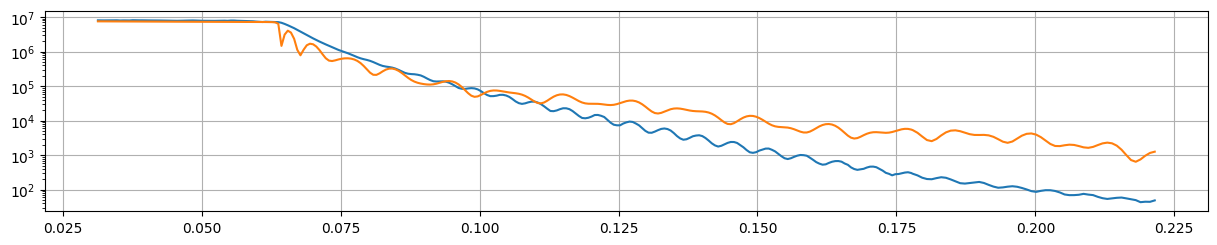

relative_loss:   0.9941107381326907 
 structure: 
 tensor([[812.3940+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 28.0566+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  79.7163+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 1.3102e-02+0.0000j,  2.3247e+00+1.8608j, -3.9342e-02+0.0000j],
        [ 2.1507e-03+0.0000j,  1.3989e+00+5.0098j, -4.4142e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  7.5529e-01+0.6108j,  4.1790e-04+0.0000j]]) 
 delta_q:   tensor(11465529., requires_grad=True) 
 grad_delta_q:   tensor(-3.1175e-08) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.027249304969595683 
 iteration:   399 



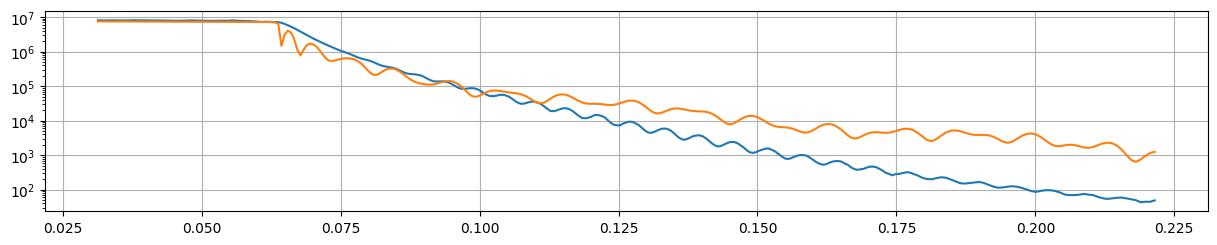

relative_loss:   0.9914616340837878 
 structure: 
 tensor([[812.0111+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 27.5545+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  80.2104+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 8.6358e-03+0.0000j,  2.6529e+00+1.8121j, -3.3505e-02+0.0000j],
        [ 1.3852e-03+0.0000j,  1.3808e+00+4.9559j, -4.3887e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  7.4458e-01+0.6092j, -3.0392e-04+0.0000j]]) 
 delta_q:   tensor(12979715., requires_grad=True) 
 grad_delta_q:   tensor(-2.1481e-07) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.02226466609724232 
 iteration:   598 



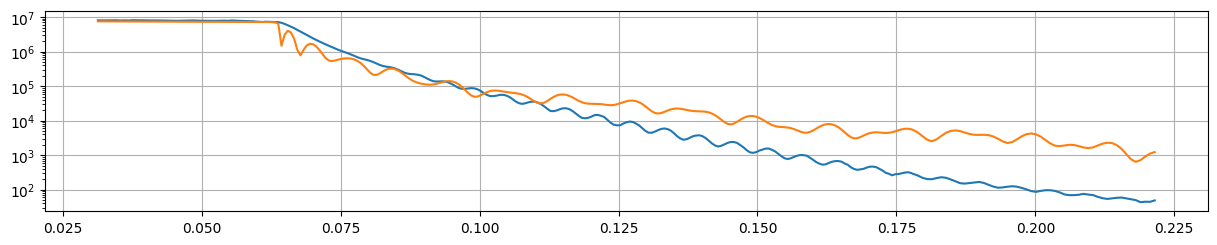

relative_loss:   0.9845793401721066 
 structure: 
 tensor([[811.3340+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 27.0248+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  80.7286+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 2.6236e-03+0.0000j,  2.4832e+00+1.8081j, -3.0008e-02+0.0000j],
        [ 6.5126e-04+0.0000j,  1.3332e+00+4.8341j, -4.3497e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  7.3026e-01+0.5904j, -9.6010e-04+0.0000j]]) 
 delta_q:   tensor(15211924., requires_grad=True) 
 grad_delta_q:   tensor(-1.3646e-07) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.018191853222487786 
 iteration:   797 



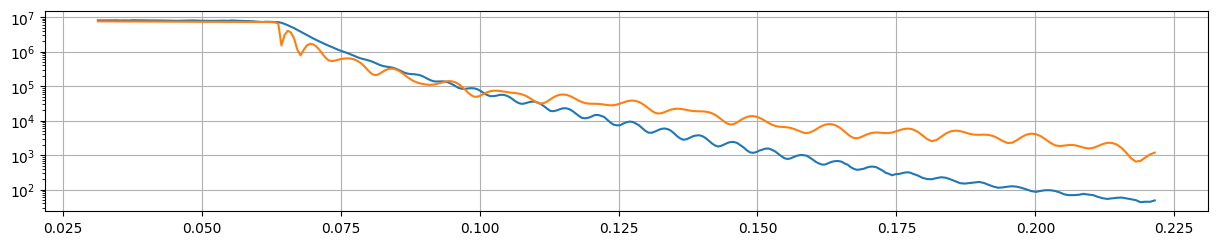

In [23]:
ans_d, ans_r_rho, ans_i_rho, ans_delta_q, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q2, ans_delta_q, r2, objective_function_pearson.objective_function,
                                                                      initial_sigma1, initial_sigma2,
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.002, max_iter = 800, k=5)

relative_loss:   1.0 
 structure: 
 tensor([[811.3065+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 26.9970+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  80.7568+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[ 2.6050e-03+0.0000j,  2.4759e+00+1.8084j, -3.0120e-02+0.0000j],
        [ 8.9070e-04+0.0000j,  1.3322e+00+4.8317j, -4.3492e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  7.3005e-01+0.5900j, -7.1965e-04+0.0000j]]) 
 delta_q:   tensor(15242545., requires_grad=True) 
 grad_delta_q:   tensor(-1.3274e-07) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.02 
 iteration:   1 



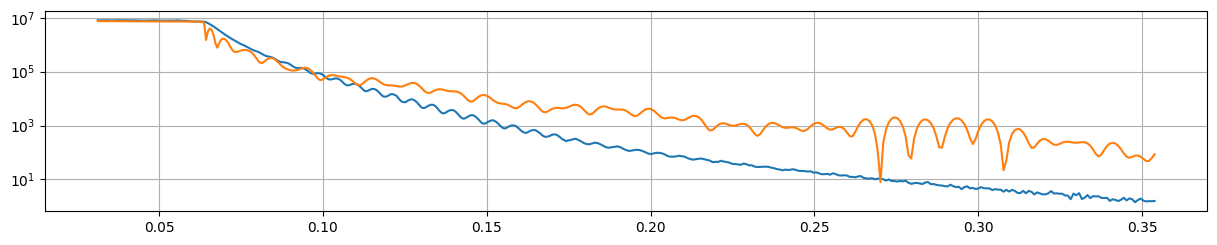

relative_loss:   0.9987411219011637 
 structure: 
 tensor([[810.8583+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 20.5925+0.0000j,   7.0000-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  87.1531+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.3956e-04+0.0000j,  2.2170e+00+1.8107j, -3.1664e-02+0.0000j],
        [ 6.6284e-04+0.0000j, -3.7275e-01+1.4054j, -4.3250e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  7.2127e-01+0.6145j, -4.5542e-04+0.0000j]]) 
 delta_q:   tensor(16596711., requires_grad=True) 
 grad_delta_q:   tensor(-4.3369e-09) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.013352159435101884 
 iteration:   400 



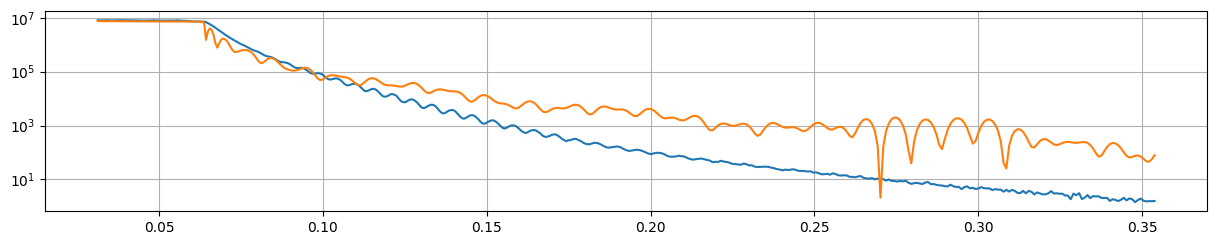

relative_loss:   0.9569452411479481 
 structure: 
 tensor([[810.8580+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 18.6066+0.0000j,   8.3975-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  89.1672+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-1.5747e-05+0.0000j,  2.0970e+00+1.7108j, -3.2507e-02+0.0000j],
        [-8.9182e-04+0.0000j, -9.1281e-01+0.2187j, -4.0149e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  6.8592e-01+0.5567j,  5.9233e-04+0.0000j]]) 
 delta_q:   tensor(16552825., requires_grad=True) 
 grad_delta_q:   tensor(9.7574e-09) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.009095926611243893 
 iteration:   799 



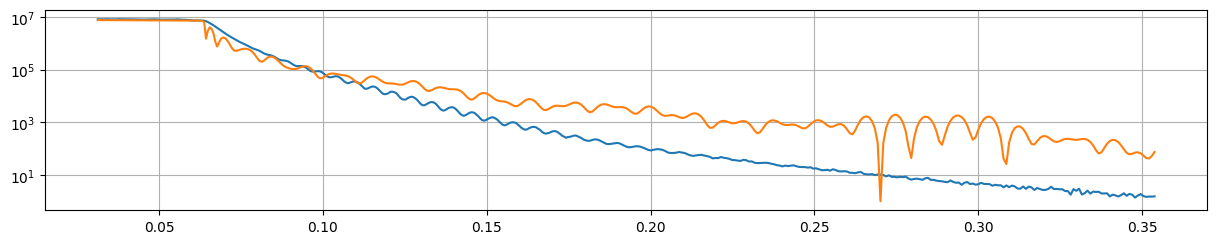

relative_loss:   0.8916662347276139 
 structure: 
 tensor([[810.9554+0.0000j,  80.0000-6.9076j, 350.0000+0.0000j],
        [ 21.5553+0.0000j,  10.7222-0.0000j,  20.0000+0.0000j],
        [100.0000+0.0000j,   7.0000-0.2109j,  86.2647+0.0000j]],
       grad_fn=<ViewBackward0>) 
 grad_structure: 
 tensor([[-9.6376e-06+0.0000j,  1.9496e+00+1.5554j, -3.2837e-02+0.0000j],
        [-2.0775e-04+0.0000j, -6.3552e-02+1.7571j, -3.5402e+00+0.0000j],
        [ 0.0000e+00+0.0000j,  6.3862e-01+0.4505j,  1.0324e-04+0.0000j]]) 
 delta_q:   tensor(16159790., requires_grad=True) 
 grad_delta_q:   tensor(1.0878e-08) 
 I:   tensor(7968744.4250, dtype=torch.float64)     grad_I:   None 
 Ibkg:   tensor(1.1000, dtype=torch.float64)     grad_Ibkg:   None 
 learning_rate:   0.006072513116165725 
 iteration:   1198 



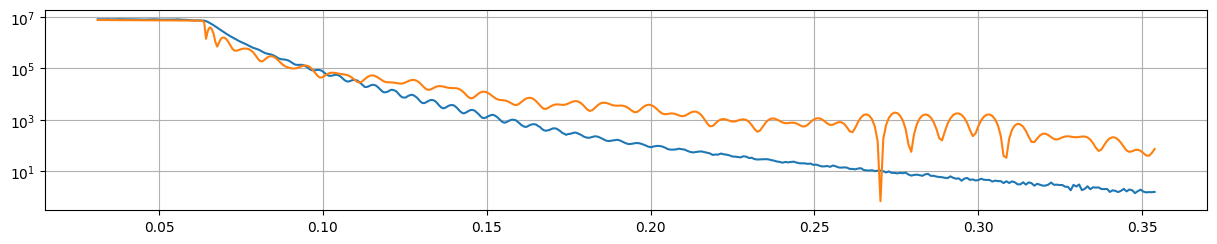

In [24]:
ans_d, ans_r_rho, ans_i_rho, ans_delta_q, ans_I, ans_Ibkg, loss, rel_losses3 = adamw(q3, ans_delta_q, r3, objective_function_pearson.objective_function,
                                                                      initial_sigma1, initial_sigma2,
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg,
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.001, max_iter = 1200, k=4)

In [25]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = list(map(lambda x: x * rel_losses2[-1],  rel_losses3))
rel_losses = rel_losses1 + rel_losses2 + rel_losses3

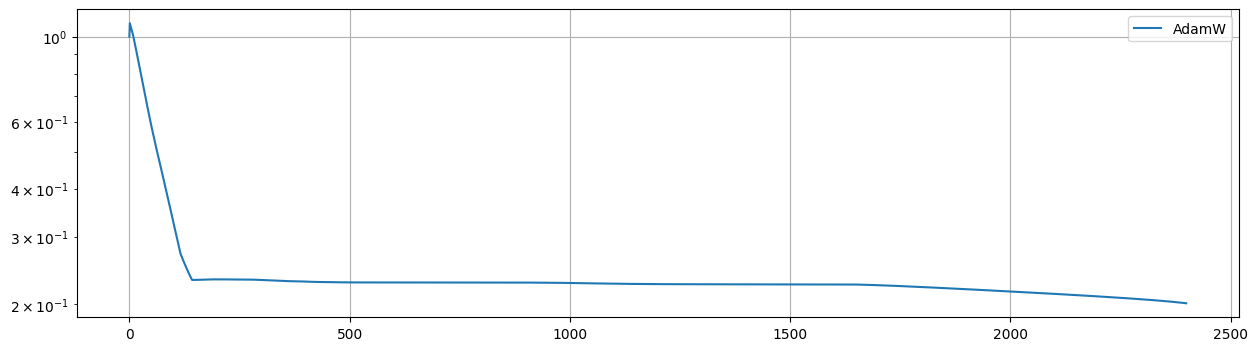

In [26]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [27]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss

(tensor([810.9557, 350.0000,  21.5633,  20.0000, 100.0000,  86.2571]),
 tensor([80.0000, 10.7437,  7.0000]),
 tensor([-6.9076, -0.0000, -0.2109]),
 tensor(7968744.4250, dtype=torch.float64),
 tensor(1.1000, dtype=torch.float64),
 62.28784818563025)

In [28]:
from add_roughness import *
matrix = torch.cat(
    (
        matr[0, :].unsqueeze(0), 
        torch.cat(
            (ans_d.reshape(-1, 2), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), 
            dim=1
        )[:, torch.tensor([0, 2, 1])]
    ), dim=0
)
q_np = q.clone().detach().cpu().numpy()
fig = plot_density_profile(transform_array(matrix, len(q_np)))
fig.show()